In [1]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("behavior-in-the-wild/LAMBDA")

df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

df = pd.concat([df_train, df_test], ignore_index=True)


C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['video_id', 'recall_score', 'youtube_id', 'ad_details'],
        num_rows: 1964
    })
    test: Dataset({
        features: ['video_id', 'recall_score', 'youtube_id', 'ad_details'],
        num_rows: 219
    })
})


In [3]:
df.columns

Index(['video_id', 'recall_score', 'youtube_id', 'ad_details'], dtype='str')

In [4]:
df.shape

(2183, 4)

In [5]:
df.head()

,video_id,recall_score,youtube_id,ad_details
0,1437,0.33,fjE8uCbWEhQ,"{'Audio': '', 'Brand': 'Mondelez International..."
1,37,0.80,3DK8I80Yhgs,"{'Audio': 'Two full meals, $5.99 each. Marparo..."
2,1806,0.86,epvlMnOO3Ew,"{'Audio': 'Zsem tolik preponenta sebohhooztih,..."
3,1055,0.57,2ZsxgpRMBDg,{'Audio': 'Who doesn't dream about having smoo...
4,1839,0.33,QVfj-EYnZ6s,"{'Audio': '', 'Brand': 'Albertsons', 'Duration..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      2183 non-null   int64  
 1   recall_score  2183 non-null   float64
 2   youtube_id    2183 non-null   str    
 3   ad_details    2183 non-null   object 
dtypes: float64(1), int64(1), object(1), str(1)
memory usage: 91.7+ KB


In [7]:
df.isna().sum()

video_id        0
recall_score    0
youtube_id      0
ad_details      0
dtype: int64

In [8]:
df.describe()

,video_id,recall_score
count,2183.000000,2183.000000
mean,1385.741182,0.611429
std,776.266313,0.280094
min,1.000000,0.000000
25%,794.500000,0.430000
50%,1431.000000,0.670000
75%,2050.500000,0.830000
max,2711.000000,1.000000


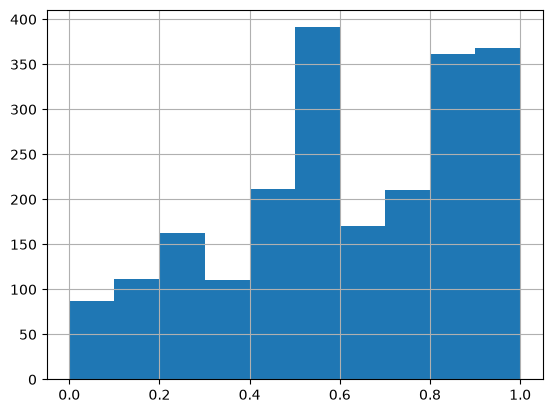

In [9]:
import matplotlib.pyplot as plt
df["recall_score"].hist()
plt.show()

In [10]:
ad_details_df = pd.DataFrame(df["ad_details"].tolist())
df_new = pd.concat([df.drop(columns=["ad_details"]), ad_details_df], axis=1)
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Scenes,Title
0,1437,0.33,fjE8uCbWEhQ,,Mondelez International,54 second,landscape,low,"[{'Colors': 'Black,Black,Gray,Dark_Gray,Off_Wh...",India - Bournvita - Basketball TV Commercial
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"[{'Colors': 'Dark_Brown,Red,Mustard,Gold,Beige...",Burger King Full Meals :15 TV Commercial
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja...",Xerox,33 second,landscape,low,"[{'Colors': 'White,White', 'Description': 'sho...",Can print embellishment really attract new cli...
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"[{'Colors': 'White,White,Dark_Gray', 'Descript...",Smooth Sexy Hair | Ulta Beauty
4,1839,0.33,QVfj-EYnZ6s,,Albertsons,52 second,square,low,"[{'Colors': 'Khaki,Brown,Off_White,Gray,Silver...",Dry-Brined Turkey Breast | Simple Weeknight Di...


In [11]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      2183 non-null   int64  
 1   recall_score  2183 non-null   float64
 2   youtube_id    2183 non-null   str    
 3   Audio         2183 non-null   str    
 4   Brand         2183 non-null   str    
 5   Duration      2183 non-null   str    
 6   Orientation   2183 non-null   str    
 7   Pace          2183 non-null   str    
 8   Scenes        2183 non-null   object 
 9   Title         2183 non-null   str    
dtypes: float64(1), int64(1), object(1), str(7)
memory usage: 1.3+ MB


In [12]:
df_new["duration_seconds"] = df_new["Duration"].str.extract(r"(\d+)").astype(float)

In [13]:
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Scenes,Title,duration_seconds
0,1437,0.33,fjE8uCbWEhQ,,Mondelez International,54 second,landscape,low,"[{'Colors': 'Black,Black,Gray,Dark_Gray,Off_Wh...",India - Bournvita - Basketball TV Commercial,54.0
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"[{'Colors': 'Dark_Brown,Red,Mustard,Gold,Beige...",Burger King Full Meals :15 TV Commercial,15.0
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja...",Xerox,33 second,landscape,low,"[{'Colors': 'White,White', 'Description': 'sho...",Can print embellishment really attract new cli...,33.0
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"[{'Colors': 'White,White,Dark_Gray', 'Descript...",Smooth Sexy Hair | Ulta Beauty,39.0
4,1839,0.33,QVfj-EYnZ6s,,Albertsons,52 second,square,low,"[{'Colors': 'Khaki,Brown,Off_White,Gray,Silver...",Dry-Brined Turkey Breast | Simple Weeknight Di...,52.0


In [14]:
df_new.describe()

,video_id,recall_score,duration_seconds
count,2183.000000,2183.000000,2183.000000
mean,1385.741182,0.611429,33.150710
std,776.266313,0.280094,13.644689
min,1.000000,0.000000,5.000000
25%,794.500000,0.430000,23.000000
50%,1431.000000,0.670000,30.000000
75%,2050.500000,0.830000,44.000000
max,2711.000000,1.000000,64.000000


In [15]:
correlation = df_new[
    ["duration_seconds", "recall_score"]
].corr(method="pearson")

print(correlation)

                  duration_seconds  recall_score
duration_seconds          1.000000      0.017888
recall_score              0.017888      1.000000


In [16]:
correlation = df_new[
    ["duration_seconds", "recall_score"]
].corr(method="spearman")

print(correlation)

                  duration_seconds  recall_score
duration_seconds          1.000000      0.017295
recall_score              0.017295      1.000000


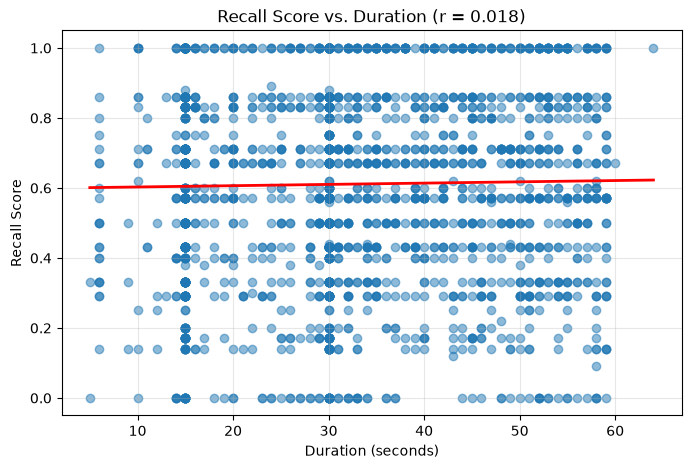

In [17]:
import numpy as np

plt.figure(figsize=(8, 5))
plt.scatter(df_new["duration_seconds"], df_new["recall_score"], alpha=0.5)

z = np.polyfit(df_new["duration_seconds"], df_new["recall_score"], 1)
x_line = np.linspace(df_new["duration_seconds"].min(), df_new["duration_seconds"].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color="red", linewidth=2)

plt.xlabel("Duration (seconds)")
plt.ylabel("Recall Score")
plt.title("Recall Score vs. Duration (r = 0.018)")
plt.grid(True, alpha=0.3)
plt.show()

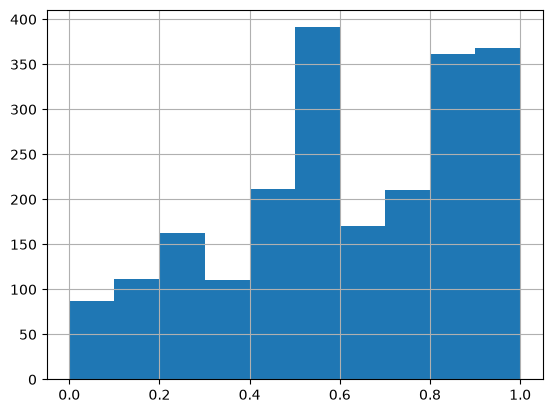

In [18]:
import matplotlib.pyplot as plt
df_new["recall_score"].hist()
plt.show()

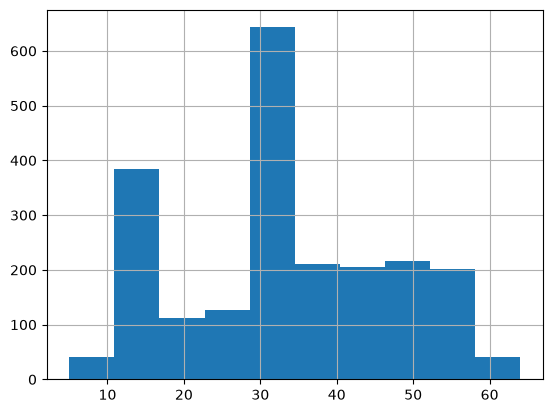

In [19]:
df_new["duration_seconds"].hist()
plt.show()

In [20]:
df_new["Brand"].value_counts()

Brand
Netflix                      121
Walt-Disney                   89
Ulta Beauty                   78
Viacom                        69
Adobe                         63
                            ... 
Henryschein                    1
L'Oreal Paris                  1
Quest Diagnostics              1
Williams                       1
American Family Insurance      1
Name: count, Length: 263, dtype: int64

In [21]:
brand_summary = pd.DataFrame({
    "Count": df_new["Brand"].value_counts(),
    "Percentage": df_new["Brand"].value_counts(normalize=True) * 100
})

brand_summary["Percentage"] = brand_summary["Percentage"].round(2)

print(brand_summary.head(10))

                   Count  Percentage
Brand                               
Netflix              121        5.54
Walt-Disney           89        4.08
Ulta Beauty           78        3.57
Viacom                69        3.16
Adobe                 63        2.89
Costco                53        2.43
Nvidia                45        2.06
Sherwin-Williams      45        2.06
Uber Technologies     38        1.74
Amazon                36        1.65


In [22]:
brand_counts = df_new["Brand"].value_counts()

print("Number of brands:", df_new["Brand"].nunique())
print("Brands appearing once:", (brand_counts == 1).sum())
print("Brands with fewer than 5 ads:", (brand_counts < 5).sum())

Number of brands: 263
Brands appearing once: 38
Brands with fewer than 5 ads: 135


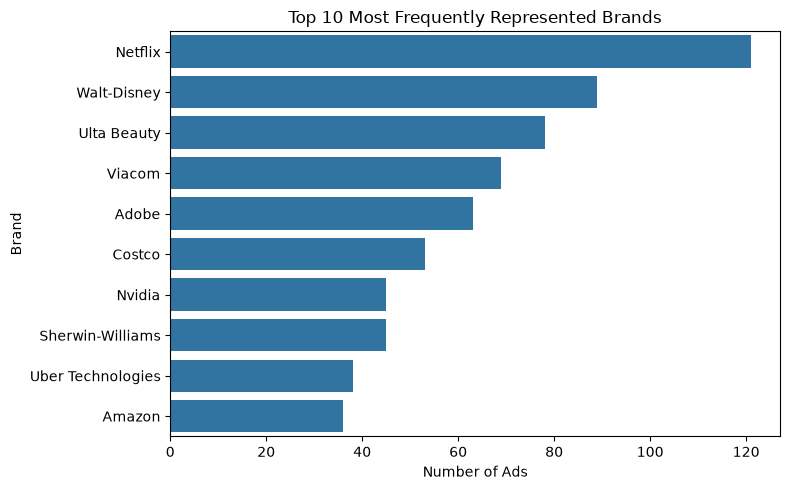

In [23]:
import seaborn as sns

top_10_brands = df_new["Brand"].value_counts().head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_brands.values,
    y=top_10_brands.index,
)

plt.xlabel("Number of Ads")
plt.ylabel("Brand")
plt.title("Top 10 Most Frequently Represented Brands")
plt.tight_layout()
plt.show()

In [24]:
brand_recall_stats = (
    df_new.groupby("Brand")["recall_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .query("count >= 10")
    .sort_values("mean", ascending=False)
    .round(3)
)

brand_recall_stats

,count,mean,median,std
Brand,,,,
Redbull,18,0.958,1.000,0.090
Netflix,121,0.887,1.000,0.159
Ford Motor Company,19,0.876,1.000,0.154
Pepsi,12,0.872,0.860,0.132
Fitbit,22,0.869,0.860,0.112
Apple,18,0.860,0.860,0.143
Louis Vuitton,15,0.845,0.860,0.155
Skechers,16,0.842,0.860,0.160
Uber Technologies,38,0.838,0.845,0.142


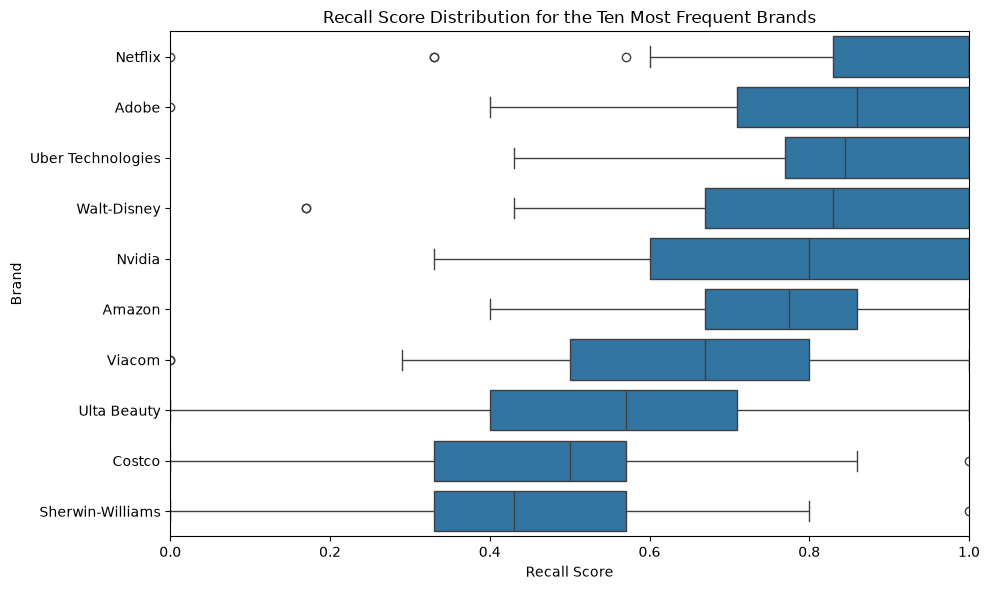

In [25]:
top_brands = df_new["Brand"].value_counts().head(10).index
top_brand_data = df_new[df_new["Brand"].isin(top_brands)].copy()

brand_order = (
    top_brand_data.groupby("Brand")["recall_score"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_brand_data,
    x="recall_score",
    y="Brand",
    order=brand_order,
   
)

plt.xlabel("Recall Score")
plt.ylabel("Brand")
plt.title("Recall Score Distribution for the Ten Most Frequent Brands")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [26]:
df_new["Pace"].value_counts()

Pace
low       1373
medium     716
high        94
Name: count, dtype: int64

In [27]:
pace_summary = pd.DataFrame({
    "Count": df_new["Pace"].value_counts(),
    "Percentage": df_new["Pace"].value_counts(normalize=True) * 100
})

pace_summary["Percentage"] = pace_summary["Percentage"].round(2)
print(pace_summary)

        Count  Percentage
Pace                     
low      1373       62.90
medium    716       32.80
high       94        4.31


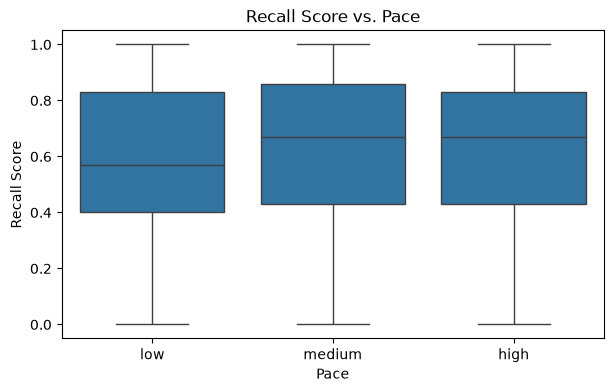

In [28]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_new,
    x="Pace",
    y="recall_score",
)

plt.xlabel("Pace")
plt.ylabel("Recall Score")
plt.title("Recall Score vs. Pace")
plt.show()

In [29]:
df_new["Orientation"].value_counts()

Orientation
landscape    2105
portrait       43
square         35
Name: count, dtype: int64

In [30]:
orientation_summary = pd.DataFrame({
    "Count": df_new["Orientation"].value_counts(),
    "Percentage": df_new["Orientation"].value_counts(normalize=True) * 100
})

orientation_summary["Percentage"] = orientation_summary["Percentage"].round(2)

print(orientation_summary)

             Count  Percentage
Orientation                   
landscape     2105       96.43
portrait        43        1.97
square          35        1.60


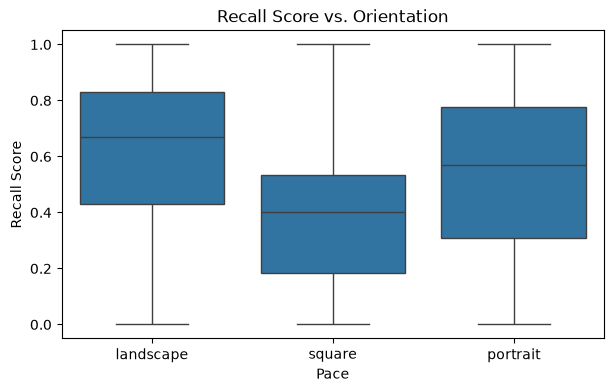

In [31]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_new,
    x="Orientation",
    y="recall_score",
)

plt.xlabel("Pace")
plt.ylabel("Recall Score")
plt.title("Recall Score vs. Orientation")
plt.show()

In [32]:
import ast

df_new['Scenes'] = df_new['Scenes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def aggregate_scenes(scenes):
    aggregated = {}
    for scene in scenes:
        for key, val in scene.items():
            if key == 'Number':
                continue
            col = f"scenes_{key.lower().replace(' ', '_')}"
            if col not in aggregated:
                aggregated[col] = set()
            if isinstance(val, str) and val.strip():
                for v in val.split(','):
                    aggregated[col].add(v.strip())

    return pd.Series({k: ', '.join(sorted(v)) for k, v in aggregated.items()})

scenes_agg = df_new['Scenes'].apply(aggregate_scenes)
df_new = pd.concat([df_new.drop(columns=['Scenes']), scenes_agg], axis=1)

In [33]:
print(df_new["scenes_colors"].value_counts(dropna=False))

scenes_colors
                                                                                                                                                                120
Black, Dark_Gray, Gray, Off_White, Silver, White                                                                                                                  6
Black, Dark_Gray, Gray                                                                                                                                            4
Black, Dark_Brown, Dark_Gray, Dark_Pink, Gray, Off_White                                                                                                          3
Black, Brown, Dark_Brown, Dark_Gray, Gray, Khaki, Mud_Green, Olive, Orange                                                                                        3
                                                                                                                                                               ... 
Bl

In [34]:
from collections import Counter

color_counts = Counter() 

df_new["scenes_colors"].dropna().apply(
    lambda x: color_counts.update([c.strip() for c in x.split(",") if c.strip()])
)

pd.Series(color_counts).sort_values(ascending=False)

Black           1902
Dark_Brown      1799
Gray            1776
Dark_Gray       1644
White           1555
Brown           1404
Dark_Blue       1280
Mud_Green       1181
Off_White       1154
Olive           1128
Orange          1005
Dark_Pink        956
Light_Blue       948
Khaki            936
Dark_Green       878
Silver           867
Royal_Blue       830
Dark_Red         771
Cyan             737
Pink             730
Red              726
Emerald          691
Lavender         559
Cream            533
Maroon           499
Purple           411
Tan              401
Light_Green      265
Blue             262
Mustard          260
Yellow           196
Turquoise        192
Beige            190
Lilac            179
Green            178
Plum             172
Magenta          107
Gold             106
Violet            88
Bright_Green      85
dtype: int64

In [35]:
color_series = df_new["scenes_colors"]

n_nan = color_series.isna().sum()


def is_empty_color(value):
    if value is None:
        return False  

    if isinstance(value, float) and np.isnan(value):
        return False  

    if isinstance(value, str):
        return value.strip() == ""

    if isinstance(value, (list, tuple, set, dict)):
        return len(value) == 0

    return False

empty_mask = color_series.apply(is_empty_color)
n_empty = empty_mask.sum()

n_total = len(df_new)
n_valid = n_total - n_nan - n_empty

print("Total ads:", n_total)
print("Valid color data:", n_valid)
print("NaN/None:", n_nan)
print("Empty values:", n_empty)
print("Missing or empty:", n_nan + n_empty)

Total ads: 2183
Valid color data: 2063
NaN/None: 0
Empty values: 120
Missing or empty: 120


In [36]:
top_colors = [color for color, count in color_counts.most_common(15)]

top_colors

['Black',
 'Dark_Brown',
 'Gray',
 'Dark_Gray',
 'White',
 'Brown',
 'Dark_Blue',
 'Mud_Green',
 'Off_White',
 'Olive',
 'Orange',
 'Dark_Pink',
 'Light_Blue',
 'Khaki',
 'Dark_Green']

In [37]:
top_15_colors = pd.DataFrame(
    color_counts.most_common(15),
    columns=["Color", "Count"]
)

total_occurrences = sum(color_counts.values())

top_15_colors["Percentage"] = (
    top_15_colors["Count"] / total_occurrences * 100
).round(2)

top_15_colors

,Color,Count,Percentage
0,Black,1902,6.43
1,Dark_Brown,1799,6.08
2,Gray,1776,6.00
3,Dark_Gray,1644,5.56
4,White,1555,5.26
5,Brown,1404,4.75
6,Dark_Blue,1280,4.33
7,Mud_Green,1181,3.99
8,Off_White,1154,3.90
9,Olive,1128,3.81


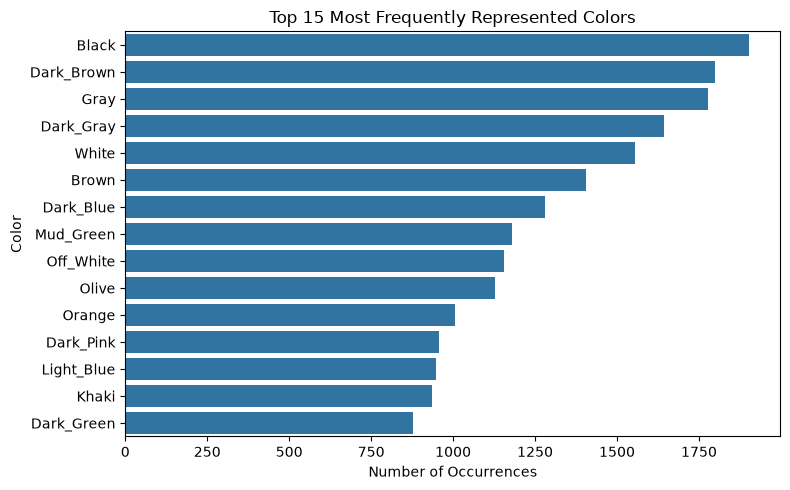

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_15_colors,
    x="Count",
    y="Color"
)

plt.xlabel("Number of Occurrences")
plt.ylabel("Color")
plt.title("Top 15 Most Frequently Represented Colors")
plt.tight_layout()
plt.show()

In [43]:
from collections import Counter

df_colors_exploded = (
    df_new[["scenes_colors", "recall_score"]]
    .dropna(subset=["scenes_colors"])
    .assign(
        scenes_colors=lambda df:
        df["scenes_colors"].str.split(",")
    )
    .explode("scenes_colors")
)

df_colors_exploded["scenes_colors"] = (
    df_colors_exploded["scenes_colors"].str.strip()
)


top_colors = (
    df_colors_exploded["scenes_colors"]
    .value_counts()
    .head(15)
    .index
)


color_recall_stats = (
    df_colors_exploded[
        df_colors_exploded["scenes_colors"].isin(top_colors)
    ]
    .groupby("scenes_colors")["recall_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .sort_values("mean", ascending=False)
    .round(3)
)

color_recall_stats

,count,mean,median,std
scenes_colors,,,,
Dark_Green,878,0.631,0.670,0.278
Dark_Blue,1280,0.625,0.670,0.278
Mud_Green,1181,0.622,0.670,0.275
Dark_Gray,1644,0.619,0.670,0.279
Black,1902,0.618,0.670,0.280
Dark_Brown,1799,0.618,0.670,0.280
Brown,1404,0.614,0.670,0.279
Orange,1005,0.612,0.670,0.277
Light_Blue,948,0.611,0.670,0.277


In [44]:
print(df_new["scenes_emotions"].value_counts(dropna=False))

scenes_emotions
abuse, achievement, anger, cheering, compete, confidence, determination, encouragement, enjoy, fancy, fun, happy, incentive, inspiration, motivation, motivational, rage, recreational, stress, success    1
, bitter, confidence, confident, delicious, dish, fancy, funky, gift, junk, positive, tasty, toast                                                                                                         1
best, betrayal, compete, concentrated, confident, excellent, gift, happiness, happy, magnificent, romance, romantic, smile, success, successful, vibrant, weird, wish                                      1
, bad, care, comfort, comfortable, disgust, disgusting, erotic, fetish, happy, laugh, love, perfect, positive, relaxation, romance, scream, smile, smiling, touching, unpleasant                           1
, bad, decay, good, protective, tasty                                                                                                                               

In [45]:
emotion_series = df_new["scenes_emotions"]


n_nan = emotion_series.isna().sum()

def is_empty_emotion(value):
    if value is None:
        return False  # đã tính trong n_nan

    if isinstance(value, float) and np.isnan(value):
        return False  # đã tính trong n_nan

    if isinstance(value, str):
        return value.strip() == ""

    if isinstance(value, (list, tuple, set, dict)):
        return len(value) == 0

    return False

empty_mask = emotion_series.apply(is_empty_emotion)

n_empty = empty_mask.sum()
n_total = len(df_new)
n_valid = n_total - n_nan - n_empty

print("Total advertisements:", n_total)
print("Valid emotion data:", n_valid)
print("NaN/None:", n_nan)
print("Empty values:", n_empty)
print("Missing or empty:", n_nan + n_empty)

Total advertisements: 2183
Valid emotion data: 2183
NaN/None: 0
Empty values: 0
Missing or empty: 0


In [46]:
from collections import Counter

emotions_counts = Counter()  

df_new["scenes_emotions"].dropna().apply(
    lambda x: emotions_counts.update([c.strip() for c in x.split(",") if c.strip()])
)

pd.Series(emotions_counts).sort_values(ascending=False)

gift                       744
happy                      725
good                       638
emergency                  519
casual                     456
                          ... 
etiquette                    1
longing                      1
enjoying a good holiday      1
sex                          1
crave                        1
Length: 1159, dtype: int64

In [47]:
top_emotions = [emotion for emotion, count in emotions_counts.most_common(15)]

top_emotions

['gift',
 'happy',
 'good',
 'emergency',
 'casual',
 'danger',
 'holiday',
 'smiling',
 'togetherness',
 'fancy',
 'achievement',
 'fun',
 'smile',
 'bad',
 'celebration']

In [48]:
df_emotions_exploded = (
    df_new[["video_id", "recall_score", "scenes_emotions"]]
    .copy()
)

df_emotions_exploded["scenes_emotions"] = (
    df_emotions_exploded["scenes_emotions"]
    .fillna("")
    .str.split(",")
)

df_emotions_exploded = df_emotions_exploded.explode("scenes_emotions")

df_emotions_exploded["scenes_emotions"] = (
    df_emotions_exploded["scenes_emotions"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_emotions_exploded = (
    df_emotions_exploded[
        df_emotions_exploded["scenes_emotions"] != ""
    ]
    .drop_duplicates(subset=["video_id", "scenes_emotions"])
)

top_emotions = (
    df_emotions_exploded["scenes_emotions"]
    .value_counts()
    .head(15)
    .index
)

emotion_recall_stats = (
    df_emotions_exploded[
        df_emotions_exploded["scenes_emotions"].isin(top_emotions)
    ]
    .groupby("scenes_emotions")["recall_score"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
    .round(3)
)

emotion_recall_stats

,count,mean,median,std
scenes_emotions,,,,
fun,390,0.677,0.71,0.276
holiday,435,0.664,0.67,0.269
bad,366,0.655,0.71,0.284
smile,380,0.651,0.71,0.271
fancy,396,0.651,0.67,0.283
danger,451,0.648,0.67,0.274
happy,725,0.641,0.67,0.272
celebration,350,0.638,0.67,0.283
casual,456,0.631,0.67,0.278
